# Notebook 2: Model development
Popularity baseline, content-based, item-kNN, SVD, hybrid, evaluation and model comparison.
Everything is imported from the `recommender` package so notebook and API use the same code.

**Protocol (fixed before we look at any numbers):**
1. Chronological leave-last-out: last rating = test, second-to-last = validation.
2. Choose model variants and hybrid weights on **validation** only.
3. Refit on train + validation and score the **test** item once.

In [1]:
import os
from pathlib import Path

# Run from the project root so `recommender` and the data/ folder are found
if Path.cwd().name == "notebooks":
    os.chdir("..")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recommender.config import DATA_DIR, GENRE_COLS, MIN_USER_RATINGS
from recommender.data import load_movielens, validate_data

pd.set_option("display.width", 140)
print("Working directory:", Path.cwd())

import evaluate as ev
from recommender.collaborative_model import ItemKNN, SVDModel
from recommender.config import COMPONENTS
from recommender.content_model import ContentModel
from recommender.evaluation import (
    catalog_coverage, intra_list_diversity, mean_popularity, rank_of_target, ranking_metrics,
)
from recommender.inference import Recommender
from recommender.preprocessing import Index, build_matrix, temporal_split
from recommender.ranking import (
    PopularityModel, RandomModel, combine, normalize_components, top_k_indices,
)

Working directory: D:\FIELD MANAGER\DATA SCIENCE ML\movie-recommender\movie-recommender


## 1. Split the data the right way
A random split would let the model train on a user's *future* ratings and test on their
past, which leaks information. Instead we hold out each user's **most recent** rating.

In [2]:
movies, ratings = load_movielens(DATA_DIR)
validate_data(movies, ratings)
splits = temporal_split(ratings, MIN_USER_RATINGS)
index = Index.build(splits.train_full.user_id, movies.movie_id)

print(f"train: {len(splits.train):,} | validation: {len(splits.val):,} | test: {len(splits.test):,}")
seen_val = build_matrix(splits.train, index, "binary").toarray() > 0
target_val = ev.targets_for(splits.val, index)
print("users:", index.n_users, "| movies:", index.n_items)

train: 98,114 | validation: 943 | test: 943
users: 943 | movies: 1682


## 2. Baselines: random and popularity
Any real model must beat **random**; a personalised model should also beat **popularity**.

In [3]:
popularity = PopularityModel().fit(splits.train, index)
top = np.argsort(-popularity.scores)[:10]
pd.DataFrame({"title": movies.set_index("movie_id").loc[index.movie_ids[top], "title"].values,
              "weighted_score": popularity.scores[top].round(3),
              "n_ratings": popularity.item_counts[top].astype(int)})

,title,weighted_score,n_ratings
0,Star Wars (1977),4.239,578
1,Schindler's List (1993),4.237,296
2,"Shawshank Redemption, The (1994)",4.210,280
3,Casablanca (1942),4.189,242
4,"Usual Suspects, The (1995)",4.158,264
5,"Godfather, The (1972)",4.138,410
6,"Silence of the Lambs, The (1991)",4.138,383
7,Raiders of the Lost Ark (1981),4.115,417
8,Rear Window (1954),4.095,200
9,One Flew Over the Cuckoo's Nest (1975),4.082,259


## 3. Content-based model
Movies are similar if their genre vectors are similar (cosine). A user's score for a movie
is its mean similarity to the movies they liked.

In [4]:
content = ContentModel().fit(movies, index)
query = movies[movies.title.str.contains("Toy Story", na=False)]
demo_movie = int(query.movie_id.iloc[0]) if len(query) else int(movies.movie_id.iloc[0])
items, scores = content.similar_items(index.movie_to_idx[demo_movie], 10)
print("Query:", movies.set_index("movie_id").loc[demo_movie, "title"])
pd.DataFrame({"title": movies.set_index("movie_id").loc[index.movie_ids[items], "title"].values,
              "similarity": scores.round(3)})

Query: Toy Story (1995)


,title,similarity
0,Aladdin and the King of Thieves (1996),1.000
1,Aladdin (1992),0.866
2,"Goofy Movie, A (1995)",0.866
3,"Santa Clause, The (1994)",0.816
4,Home Alone (1990),0.816
5,"Aristocats, The (1970)",0.816
6,D3: The Mighty Ducks (1996),0.816
7,"Love Bug, The (1969)",0.816
8,"Wrong Trousers, The (1993)",0.816
9,"Grand Day Out, A (1992)",0.816


**Observation:** many results have similarity exactly 1.0 because they share the same
genres. Genre-only content is coarse, so it is better as one signal inside the hybrid than alone.

## 4. Item-item collaborative filtering
Similarity comes from *how users rated* the movies, not from metadata. We try three rating
signals: `raw` (1-5), `binary` (did they rate it) and `centered` (rating minus the user's mean).
**Hypothesis to test, not assume:** mean-centering helps rating prediction, but our task is
ranking *which movie a user rates next*, where the implicit signal (`binary`) may compete.

In [5]:
knn_variants = {s: ItemKNN(s).fit(splits.train, index) for s in ev.KNN_SIGNALS}
knn = knn_variants["centered"]
items, scores = knn.similar_items(index.movie_to_idx[demo_movie], 10)
print("Collaborative neighbours of:", movies.set_index("movie_id").loc[demo_movie, "title"])
pd.DataFrame({"title": movies.set_index("movie_id").loc[index.movie_ids[items], "title"].values,
              "similarity": scores.round(3)})

Collaborative neighbours of: Toy Story (1995)


,title,similarity
0,Raiders of the Lost Ark (1981),0.271
1,Star Wars (1977),0.241
2,Beauty and the Beast (1991),0.229
3,Apollo 13 (1995),0.221
4,Indiana Jones and the Last Crusade (1989),0.201
5,Aladdin (1992),0.201
6,"Empire Strikes Back, The (1980)",0.198
7,Return of the Jedi (1983),0.184
8,Braveheart (1995),0.183
9,Schindler's List (1993),0.182


## 5. SVD (matrix factorisation)
Compress the user-item matrix into 20 latent factors and score items by reconstruction.

In [6]:
svd_variants = {s: SVDModel(s).fit(splits.train, index) for s in ev.SVD_SIGNALS}
print("fitted SVD variants:", list(svd_variants))

fitted SVD variants: ['centered', 'binary', 'raw']


## 6. Compare every variant on the validation set
Recall@10 equals HitRate@10 here because each user has exactly one relevant item.

In [7]:
variants = {"random": RandomModel(), "popularity": popularity, "content": content}
variants.update({f"knn_{s}": m for s, m in knn_variants.items()})
variants.update({f"svd_{s}": m for s, m in svd_variants.items()})

val_scores = ev.score_models(variants, splits.train, index)
val_table = pd.DataFrame(
    {name: ev.evaluate_scores(s, seen_val, target_val) for name, s in val_scores.items()}
).T
val_table[["Recall@10", "MAP@10", "NDCG@10", "MRR"]].round(4).sort_values("NDCG@10", ascending=False)

,Recall@10,MAP@10,NDCG@10,MRR
svd_raw,0.1294,0.0458,0.0653,0.0614
svd_binary,0.1326,0.0432,0.0638,0.0589
knn_raw,0.1156,0.0413,0.0584,0.0566
knn_binary,0.1145,0.0367,0.0546,0.0517
svd_centered,0.0700,0.0288,0.0384,0.0357
knn_centered,0.0700,0.0262,0.0363,0.0347
popularity,0.0520,0.0161,0.0242,0.0226
content,0.0106,0.0038,0.0054,0.0083
random,0.0042,0.0011,0.0019,0.0045


In [8]:
best_knn = max(ev.KNN_SIGNALS, key=lambda s: val_table.loc[f"knn_{s}", "NDCG@10"])
best_svd = max(ev.SVD_SIGNALS, key=lambda s: val_table.loc[f"svd_{s}", "NDCG@10"])
print("best kNN signal:", best_knn, "| best SVD signal:", best_svd)

best kNN signal: raw | best SVD signal: raw


**Write in your own words:** which signal won for each model, and why might that be?
Did mean-centering help or not on *this* task?

## 7. Hybrid: tune the blend on validation
Scores from different models live on different scales, so each is min-max normalised per
user (over unseen movies only) and then combined with weights that sum to 1. We search a grid
of weights and keep the best validation NDCG@10.

In [9]:
components = {
    "knn": val_scores[f"knn_{best_knn}"],
    "svd": val_scores[f"svd_{best_svd}"],
    "content": val_scores["content"],
    "popularity": val_scores["popularity"],
}
normalized = normalize_components(components, seen_val)

rows = []
for w in ev.weight_grid(COMPONENTS, 0.1):
    final = combine(normalized, w, seen_val)
    ndcg = ranking_metrics(rank_of_target(final, seen_val, target_val), ks=(10,))["NDCG@10"]
    rows.append({**w, "val_NDCG@10": ndcg})
grid = pd.DataFrame(rows).sort_values("val_NDCG@10", ascending=False)
best_weights = {c: float(grid.iloc[0][c]) for c in COMPONENTS}
print("best weights:", best_weights)
grid.head(8).round(4)

best weights: {'knn': 0.0, 'svd': 0.9, 'content': 0.1, 'popularity': 0.0}


,knn,svd,content,popularity,val_NDCG@10
64,0.0,0.9,0.1,0.0,0.0683
116,0.1,0.7,0.1,0.1,0.0680
161,0.2,0.6,0.1,0.1,0.0679
119,0.1,0.8,0.1,0.0,0.0676
61,0.0,0.8,0.1,0.1,0.0671
117,0.1,0.7,0.2,0.0,0.0668
63,0.0,0.9,0.0,0.1,0.0667
164,0.2,0.7,0.1,0.0,0.0665


## 8. Final test evaluation (score the test item once)
Refit on train + validation, use the settings chosen above, and add beyond-accuracy metrics.

In [10]:
seen_test = build_matrix(splits.train_full, index, "binary").toarray() > 0
target_test = ev.targets_for(splits.test, index)
parts = ev.fit_components(splits.train_full, movies, index, best_knn, best_svd)
raw = ev.score_models({"random": RandomModel(), **parts}, splits.train_full, index)
norm = normalize_components({n: raw[n] for n in COMPONENTS}, seen_test)

finals = {
    "random": raw["random"], "popularity": raw["popularity"], "content": raw["content"],
    f"knn ({best_knn})": raw["knn"], f"svd ({best_svd})": raw["svd"],
    "HYBRID (tuned)": combine(norm, best_weights, seen_test),
}
for dropped in COMPONENTS:  # ablation
    rest = {n: w for n, w in best_weights.items() if n != dropped}
    if sum(rest.values()) > 0:
        rest = {n: w / sum(rest.values()) for n, w in rest.items()}
        finals[f"hybrid without {dropped}"] = combine(norm, rest, seen_test)

table = {}
for name, s in finals.items():
    m = ev.evaluate_scores(s, seen_test, target_test)
    top10 = top_k_indices(s, 10)
    m["Coverage@10"] = catalog_coverage(top10, index.n_items)
    m["AvgPopularity@10"] = mean_popularity(top10, parts["popularity"].item_counts)
    m["Diversity@10"] = intra_list_diversity(top10, parts["content"].similarity)
    table[name] = m
test_table = pd.DataFrame(table).T.round(4)
test_table[["Precision@10", "Recall@10", "MAP@10", "NDCG@10", "MRR", "Coverage@10", "Diversity@10"]]

,Precision@10,Recall@10,MAP@10,NDCG@10,MRR,Coverage@10,Diversity@10
random,0.0005,0.0053,0.0015,0.0024,0.0046,0.9958,0.7712
popularity,0.0030,0.0297,0.0082,0.0130,0.0134,0.0059,0.7100
content,0.0020,0.0201,0.0064,0.0097,0.0104,0.4566,0.0943
knn (raw),0.0083,0.0827,0.0239,0.0375,0.0364,0.1950,0.6558
svd (raw),0.0083,0.0827,0.0240,0.0375,0.0372,0.1350,0.6587
HYBRID (tuned),0.0084,0.0838,0.0245,0.0382,0.0378,0.2812,0.6639
hybrid without knn,0.0084,0.0838,0.0245,0.0382,0.0378,0.2812,0.6639
hybrid without svd,0.0020,0.0201,0.0064,0.0097,0.0104,0.4560,0.0975
hybrid without content,0.0083,0.0827,0.0240,0.0375,0.0372,0.2741,0.7090
hybrid without popularity,0.0084,0.0838,0.0245,0.0382,0.0378,0.2812,0.6639


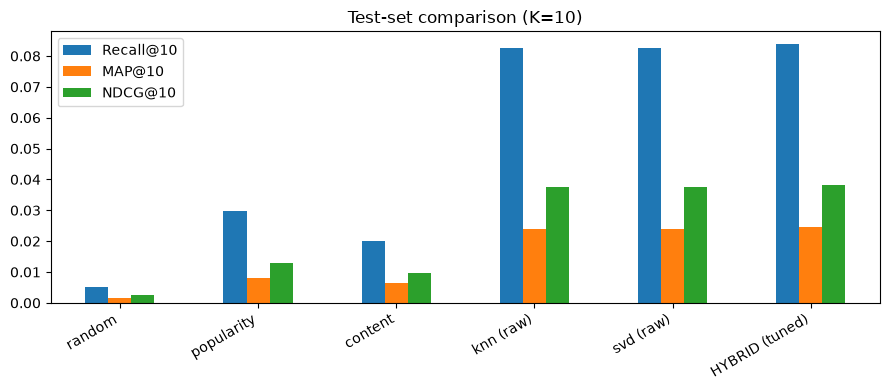

In [11]:
main = [r for r in test_table.index if not r.startswith("hybrid without")]
test_table.loc[main, ["Recall@10", "MAP@10", "NDCG@10"]].plot(kind="bar", figsize=(9, 4))
plt.title("Test-set comparison (K=10)"); plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.show()

**Read the ablation rows:** if removing a component barely changes the score, it is not
pulling its weight. Compare accuracy against coverage and diversity: the most accurate model is not
always the best product.

## 9. Using the trained system: personalised, cold start, similar movies
`Recommender.fit` trains on **all** ratings, which is what the API serves.

In [12]:
rec = Recommender(knn_signal=best_knn, svd_signal=best_svd, weights=best_weights).fit(movies, ratings)
user = int(rec.index.user_ids[0])
print(f"Hybrid recommendations for user {user}")
display(rec.recommend_for_user(user, k=5)[["movie_id", "title", "score"]])
print("Cold start (unknown user, likes Drama)")
display(rec.recommend_for_user(999_999, k=5, preferred_genres=["Drama"])[["movie_id", "title", "score"]])
print("Similar movies (collaborative)")
display(rec.similar_movies(demo_movie, k=5, mode="collaborative")[["movie_id", "title", "score"]])

Hybrid recommendations for user 1


,movie_id,title,score
0,475,Trainspotting (1996),0.989114
1,423,E.T. the Extra-Terrestrial (1982),0.836696
2,275,Sense and Sensibility (1995),0.822823
3,318,Schindler's List (1993),0.821666
4,403,Batman (1989),0.816479


Cold start (unknown user, likes Drama)


,movie_id,title,score
0,318,Schindler's List (1993),1.495445
1,64,"Shawshank Redemption, The (1994)",1.476698
2,483,Casablanca (1942),1.461875
3,127,"Godfather, The (1972)",1.424124
4,98,"Silence of the Lambs, The (1991)",1.422799


Similar movies (collaborative)


,movie_id,title,score
0,50,Star Wars (1977),0.715785
1,181,Return of the Jedi (1983),0.679927
2,121,Independence Day (ID4) (1996),0.668496
3,117,"Rock, The (1996)",0.642329
4,405,Mission: Impossible (1996),0.618169


## 10. Conclusions (fill in from YOUR results)
1. Best single model and by how much it beats popularity: ...
2. Did the hybrid beat every single model? Which ablation mattered most: ...
3. Accuracy vs coverage/diversity trade-off: ...
4. Limitations of this evaluation (one held-out item per user, offline only): ...
5. What I would try next: ...